# Clasificación de sentimiento de reseñas — Parte 1 (ML clásico)

Aprendizaje de Máquina 2026-20, Universidad de los Andes.

**Objetivo:** clasificar reseñas de productos en español en `negativo`, `neutral` o `positivo` usando únicamente
modelos de scikit-learn y representaciones clásicas (bag-of-words, TF-IDF, n-gramas).

**Contenido**
0. Configuración y carga de datos
1. Exploración de los datos
2. Preprocesamiento (normalización del texto)
3. Esquema de validación, métricas y funciones auxiliares
4. Experimento 1 — Línea base: TF-IDF (1,2) + Regresión logística

## 0. Configuración y carga de datos

### 0.1 Librerías y semilla

In [1]:
import re
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score, cross_val_predict
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay
from sklearn.base import clone

# Semilla fija para que todos los resultados sean replicables
SEED = 42
np.random.seed(SEED)

# Orden y color fijo de las clases en todo el notebook
CLASES = ["negativo", "neutral", "positivo"]
COLORES = {"negativo": "#2a78d6", "neutral": "#eb6834", "positivo": "#1baf7a"}

pd.set_option("display.max_colwidth", 200)
plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.axisbelow": True,
})

### 0.2 Carga de datos

Se cargan los archivos originales y se trabaja sobre copias (`.copy()`) para no modificar los datos crudos.
`eval.csv` **no tiene etiqueta**: solo se usa para generar las predicciones que se envían a Kaggle, nunca para entrenar.

In [2]:
train_raw = pd.read_csv("train.csv")
eval_raw = pd.read_csv("eval.csv")
sample_submission = pd.read_csv("sample_submission.csv")

train = train_raw.copy()
eval_df = eval_raw.copy()

print("train:", train.shape)
print("eval:", eval_df.shape)
print("sample_submission:", sample_submission.shape)

train: (12000, 3)
eval: (3000, 2)
sample_submission: (3000, 2)


In [3]:
train.head()

,id,text,label
0,0,"Lo pedí un martes por la noche y me llegó al día siguiente. Es el modelo en color negro, el básico de la línea. Lo pesé en la báscula de la cocina y marca algo más de medio kilo. Lo tengo en el es...",neutral
1,1,"Se lo compré a un familiar después de pensarla varias semanas, llegó en unos cuatro días a mi casa. La verdad sea dicha, el soporte técnico me resultó incumplidor para lo que necesitaba, tardaban ...",positivo
2,2,"Lo pedí a mediados de mes y me llegó en tres días, en su caja normal sin nada fuera de lo común. Lo uso en la oficina casi a diario desde entonces. El diseño se sintió durable desde el primer día....",negativo
3,3,"Compré esto en línea y llegó en unos tres días a la casa. Venían varias unidades en el paquete, revisé todas una por una. El ensamblaje terminó siendo impreciso para lo que necesitaba, la verdad. ...",negativo
4,4,"Compré este kit el mes pasado porque necesitaba algo para las videollamadas del trabajo, llegó en tres días a casa. La verdad, el cargador me pareció terrible para mi gusto. Lo uso casi todos los ...",positivo


In [4]:
eval_df.head()

,id,text
0,0,"Hice el pedido desde la aplicacion un martes por la tarde y llego a mi casa al dia siguiente. El paquete venia bien cerrado y, de paquete, traia ademas una bolsa de tela. Esa bolsa la estoy usando..."
1,1,"Compre esto a principios de mes porque andaba necesitando uno, llego en unos cuantos dias a mi casa. Al principio el rendimiento me parecio flojo tras el primer mes, la verdad le tenia fe pero ahi..."
2,2,"Lo pedí un martes y me llegó el jueves a la casa. Lo compré para reemplazar uno anterior que ya tenía en el cuarto de baño. Viene en cuatro tamaños distintos, así que alcanza para varias personas...."
3,3,"Me llegó el miércoles pasado, tres días después de hacer el pedido. Lo pruebo casi a diario desde hace poco, nomás lo saco un rato en las tardes. Mide como veinte centímetros y cabe sin problema e..."
4,4,"Lo pedí un martes y llegó el jueves a la casa. En el paquete venían dos unidades, tal cual. Las medidas coinciden con lo que dice la descripción. Las medí con una cinta métrica apenas las recibí p..."


In [5]:
sample_submission.head()

,id,answer
0,0,neutral
1,1,neutral
2,2,neutral
3,3,neutral
4,4,neutral


## 1. Exploración de los datos

Antes de modelar se revisa: la estructura y calidad básica, la distribución de clases, la longitud de los textos,
la presencia de conectores contrastivos y negaciones (el núcleo de la dificultad del problema), ejemplos reales,
el ruido del texto y los n-gramas más frecuentes por clase.

### 1.1 Estructura y calidad básica

In [6]:
calidad = pd.DataFrame({
    "chequeo": [
        "Nulos en train",
        "Nulos en eval",
        "ids repetidos en train",
        "Textos duplicados en train",
        "Textos de eval que también están en train",
        "ids de eval iguales a los de sample_submission",
    ],
    "resultado": [
        int(train.isna().sum().sum()),
        int(eval_df.isna().sum().sum()),
        int(train["id"].duplicated().sum()),
        int(train["text"].duplicated().sum()),
        int(eval_df["text"].isin(train["text"]).sum()),
        bool(set(eval_df["id"]) == set(sample_submission["id"])),
    ],
})
calidad

,chequeo,resultado
0,Nulos en train,0
1,Nulos en eval,0
2,ids repetidos en train,0
3,Textos duplicados en train,0
4,Textos de eval que también están en train,0
5,ids de eval iguales a los de sample_submission,True


### 1.2 Distribución de clases

,reseñas,%
label,,
negativo,4212,35.1
neutral,3576,29.8
positivo,4212,35.1


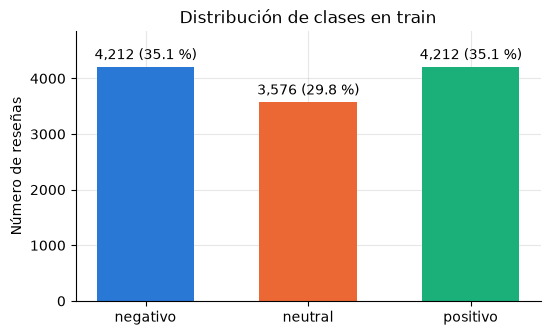

Accuracy de predecir siempre la clase mayoritaria: 0.351


In [7]:
conteo = train["label"].value_counts().reindex(CLASES)
porcentaje = (conteo / conteo.sum() * 100).round(1)
display(pd.DataFrame({"reseñas": conteo, "%": porcentaje}))

fig, ax = plt.subplots(figsize=(6, 3.5))
barras = ax.bar(CLASES, conteo.values, color=[COLORES[c] for c in CLASES], width=0.6)
ax.bar_label(barras, labels=[f"{n:,} ({p} %)" for n, p in zip(conteo.values, porcentaje.values)], padding=3)
ax.set_ylabel("Número de reseñas")
ax.set_title("Distribución de clases en train")
ax.set_ylim(0, conteo.max() * 1.15)
plt.show()

print(f"Accuracy de predecir siempre la clase mayoritaria: {conteo.max() / conteo.sum():.3f}")

### 1.3 Longitud de las reseñas

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
negativo,4212.0,54.2,12.7,6.0,48.0,54.0,61.0,100.0
neutral,3576.0,52.3,13.9,3.0,46.0,52.0,60.0,96.0
positivo,4212.0,55.0,13.0,5.0,48.0,55.0,62.0,110.0


eval, palabras por reseña:


,count,mean,std,min,25%,50%,75%,max
n_palabras,3000.0,54.2,13.1,4.0,48.0,54.0,61.0,104.0


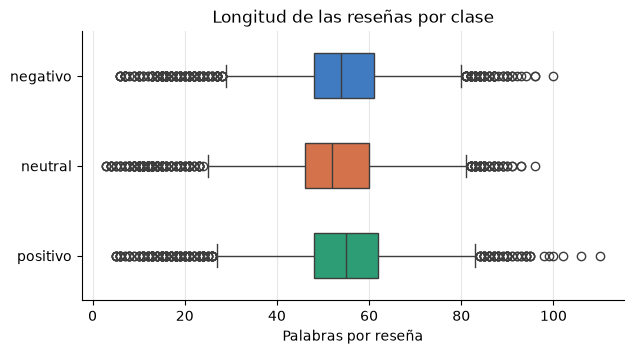

In [8]:
train["n_palabras"] = train["text"].str.split().str.len()
train["n_caracteres"] = train["text"].str.len()
eval_df["n_palabras"] = eval_df["text"].str.split().str.len()

display(train.groupby("label")["n_palabras"].describe().reindex(CLASES).round(1))
print("eval, palabras por reseña:")
display(eval_df["n_palabras"].describe().round(1).to_frame().T)

fig, ax = plt.subplots(figsize=(7, 3.5))
sns.boxplot(data=train, x="n_palabras", y="label", hue="label", order=CLASES,
            palette=COLORES, legend=False, width=0.5, ax=ax)
ax.set_xlabel("Palabras por reseña")
ax.set_ylabel("")
ax.set_title("Longitud de las reseñas por clase")
plt.show()

### 1.4 Conectores contrastivos y negación

El enunciado advierte que el sentimiento global depende del orden, la negación y los conectores contrastivos.
Se mide en qué porcentaje de reseñas de cada clase aparece cada marcador (búsqueda sin distinguir mayúsculas ni tildes).

In [9]:
TILDES = str.maketrans("áéíóúàèìòùäëïöüâêîôû", "aeiouaeiouaeiouaeiou")
texto_basico = train["text"].str.lower().str.translate(TILDES)

MARCADORES = {
    "pero": r"\bpero\b",
    "aunque": r"\baunque\b",
    "sin embargo": r"\bsin embargo\b",
    "aun asi": r"\baun asi\b",
    "en cambio": r"\ben cambio\b",
    "por otro lado": r"\bpor otro lado\b",
    "al final": r"\bal final\b",
    "en fin": r"\ben fin\b",
    "la verdad": r"\bla verdad\b",
    "no": r"\bno\b",
    "ni": r"\bni\b",
    "nada": r"\bnada\b",
    "nunca": r"\bnunca\b",
    "sin": r"\bsin\b",
}

presencia = pd.DataFrame({m: texto_basico.str.contains(p, regex=True) for m, p in MARCADORES.items()})
pct_marcadores = (presencia.groupby(train["label"]).mean().T[CLASES] * 100).round(1)
pct_marcadores["total"] = (presencia.mean() * 100).round(1)
pct_marcadores

label,negativo,neutral,positivo,total
pero,9.5,3.7,3.8,5.8
aunque,4.9,2.7,3.9,3.9
sin embargo,1.5,0.0,1.4,1.0
aun asi,7.4,0.0,10.4,6.3
en cambio,0.3,0.0,0.5,0.3
por otro lado,7.3,3.6,7.2,6.1
al final,13.9,0.7,13.7,9.9
en fin,1.4,0.1,1.5,1.0
la verdad,36.3,2.3,38.7,27.0
no,27.1,40.6,25.9,30.7


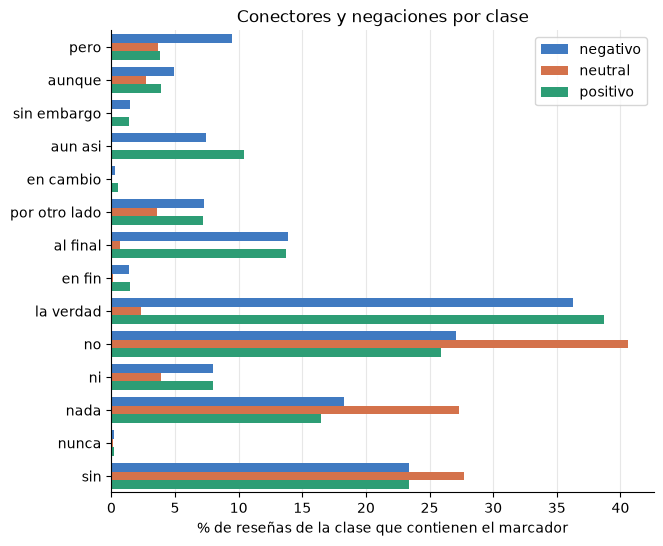

In [10]:
largo = pct_marcadores[CLASES].reset_index(names="marcador").melt(
    id_vars="marcador", var_name="clase", value_name="pct")

fig, ax = plt.subplots(figsize=(7, 6))
sns.barplot(data=largo, y="marcador", x="pct", hue="clase", hue_order=CLASES,
            palette=COLORES, orient="h", ax=ax)
ax.set_xlabel("% de reseñas de la clase que contienen el marcador")
ax.set_ylabel("")
ax.set_title("Conectores y negaciones por clase")
ax.legend(title="")
plt.show()

### 1.5 Ejemplos por clase

In [11]:
for clase in CLASES:
    print(f"==================== {clase.upper()} ====================")
    for texto in train.loc[train["label"] == clase, "text"].sample(2, random_state=SEED):
        print(texto, "\n")

==================== NEGATIVO ====================
La compré en noviembre en una oferta del buen fin, llegó en cuatro días. En pocas palabras, la cámara no es para nada lo que esperaba. La uso nomás para fotos casuales en casa. Además, la interfaz fue todo un acierto, la uso a diario y la dejo igual que cuando llegó. 

Lo compre hace poco por internet porque queria reemplazar uno viejo que tenia en la casa. Me llego en unos trs dias. La autonoia me salio eficiente para lo que necesitaba, la uso a diario en las mananas. Eso si, el tamano es de mala calidad hasta ahora. 

==================== NEUTRAL ====================
Lo pedí un martes por la tarde porque justo andaba cerca de la oficina donde lo iba a usar. Llegó en menos de tres días, o sea que el jueves ya lo tenía en casa. Lo entregó la mensajería de siempre, el mismo señor que suele pasar por la cuadra, y me lo dejó en la recepción porque no estaba. La caja venía cerrada con su plástico. Trae garantía de seis meses según el papel

### 1.6 Ruido en el texto

Se buscan de forma automática (con conteos y expresiones regulares sobre todas las filas) problemas de codificación,
tildes inconsistentes, errores de tipeo y otros patrones que la normalización debe tratar.

In [12]:
def contiene(serie, patron):
    """Serie booleana: True si el texto contiene el patrón (admite grupos de captura)."""
    return serie.map(lambda t: re.search(patron, t) is not None)


PATRONES_RUIDO = {
    "mojibake (Ã)": r"Ã",
    "tildes graves (à è ì ò ù)": r"[àèìòù]",
    "letra repetida 3+ veces": r"([a-záéíóúñ])\1\1",
    "palabra en MAYÚSCULAS (3+ letras)": r"\b[A-ZÁÉÍÓÚÑ]{3,}\b",
    "contiene dígitos": r"\d",
}

ruido = pd.DataFrame({
    "train": {n: int(contiene(train["text"], p).sum()) for n, p in PATRONES_RUIDO.items()},
    "eval": {n: int(contiene(eval_df["text"], p).sum()) for n, p in PATRONES_RUIDO.items()},
})
ruido

,train,eval
mojibake (Ã),2,0
tildes graves (à è ì ò ù),1,0
letra repetida 3+ veces,8,0
palabra en MAYÚSCULAS (3+ letras),743,182
contiene dígitos,1126,241


In [13]:
def mostrar_contexto(patron, n=2, ancho=70):
    """Imprime el fragmento alrededor de la primera coincidencia en n reseñas."""
    filas = train[contiene(train["text"], patron)].head(n)
    for _, fila in filas.iterrows():
        m = re.search(patron, fila["text"])
        ini, fin = max(0, m.start() - ancho), m.end() + ancho
        print(f"  [{fila['label']}] ...{fila['text'][ini:fin]}...")

for nombre, patron in PATRONES_RUIDO.items():
    print(nombre)
    mostrar_contexto(patron)
    print()

mojibake (Ã)
  [neutral] ...Pues aquÃ­ va lo prometido, mi reseÃ±a del artÃ­culo. Me llegÃ³ el martes por l...
  [neutral] ...Hace poco lo comprÃ© por internet para reemplazar otro que tenÃ­a en casa desde hacÃ­a aÃ...

tildes graves (à è ì ò ù)
  [neutral] ...Pues aquì va mi reseña. El paquete llegò en cuatro dìas y lo trajo la mensajerì...

letra repetida 3+ veces
  [positivo] ... dias. Me encanto la portabilidad de principio a fin. Por cierto, me arrrepiento de haber elegido la atencion al cliente. Ni tan bueno ni tan m...
  [negativo] ... para el trabajo diario. La instalacion me costo, le pondria una estrellla a esa parte. La memoria en cambio quedo encantada, la verdad muy con...

palabra en MAYÚSCULAS (3+ letras)
  [negativo] ...a. La carga es por un conector magnético en un puerto propio, nada de USB normal. Me decepcionó la construcción de principio a fin, la verdad. ...
  [neutral] ...ondo, le di varios usos seguidos para ver como venia. Carga por micro USB, o sea que hay que

In [14]:
# Vocabulario: palabras escritas de varias formas (con/sin tilde) y palabras que aparecen una sola vez
frecuencias = Counter(t for texto in train["text"].str.lower() for t in re.findall(r"\w+", texto))

variantes = {}
for palabra in frecuencias:
    variantes.setdefault(palabra.translate(TILDES), set()).add(palabra)
grupos_tilde = [sorted(v) for v in variantes.values() if len(v) > 1]

hapax = [p for p, f in frecuencias.items() if f == 1]

print(f"Palabras distintas (en minúscula): {len(frecuencias):,}")
print(f"Palabras con varias escrituras por tildes: {len(grupos_tilde):,} grupos, p. ej. {grupos_tilde[:6]}")
print(f"Palabras que aparecen una sola vez (hapax): {len(hapax):,} ({len(hapax) / len(frecuencias):.0%} del vocabulario)")
print("Ejemplos de hapax:", hapax[:30])

Palabras distintas (en minúscula): 6,054
Palabras con varias escrituras por tildes: 507 grupos, p. ej. [['pedi', 'pedí'], ['llego', 'llegò', 'llegó'], ['dia', 'día'], ['el', 'él'], ['basico', 'básico'], ['linea', 'línea']]
Palabras que aparecen una sola vez (hapax): 2,416 (40% del vocabulario)
Ejemplos de hapax: ['pensarla', 'tardaban', 'ríen', 'desordenado', 'gestión', 'acabarla', 'amolar', 'teenr', 'arrrepiento', 'receptor', 'armábamos', 'meediano', 'windows', 'contestan', 'reelacion', 'sostuve', 'coomprar', 'exhibicion', 'confirmarlo', 'pan', 'reppisa', 'conuslto', 'remisión', 'entendía', 'familiarizarme', 'entienden', 'crema', 'fabriante', 'toods', 'usuario']


In [15]:
# ¿El ruido está asociado a alguna clase? (posible pista falsa para el modelo)
asociacion = pd.DataFrame({
    n: train.loc[contiene(train["text"], p), "label"].value_counts().reindex(CLASES, fill_value=0)
    for n, p in PATRONES_RUIDO.items()
}).T
asociacion

label,negativo,neutral,positivo
mojibake (Ã),0,2,0
tildes graves (à è ì ò ù),0,1,0
letra repetida 3+ veces,2,0,6
palabra en MAYÚSCULAS (3+ letras),133,455,155
contiene dígitos,203,722,201


In [16]:
# Las palabras en mayúscula, ¿qué son?
mayusculas = Counter(m for texto in train["text"] for m in re.findall(r"\b[A-ZÁÉÍÓÚÑ]{3,}\b", texto))
mayusculas.most_common(15)

[('USB', 548),
 ('AAA', 178),
 ('HDMI', 19),
 ('RAM', 8),
 ('USBC', 3),
 ('GPS', 1),
 ('CPU', 1),
 ('CDMX', 1),
 ('AAAA', 1),
 ('OXXO', 1)]

### 1.7 Bigramas más frecuentes por clase

Si los bigramas más frecuentes son casi los mismos en las tres clases, significa que gran parte del texto es relleno
compartido (compra, envío, uso) que no ayuda a distinguir el sentimiento. Esto motiva usar TF-IDF, que reduce el peso
de los términos presentes en muchas reseñas.

In [17]:
def top_ngramas(textos, n=10, ngram=(2, 2)):
    vec = CountVectorizer(ngram_range=ngram)
    X = vec.fit_transform(textos)
    totales = np.asarray(X.sum(axis=0)).ravel()
    orden = totales.argsort()[::-1][:n]
    return [f"{vec.get_feature_names_out()[i]} ({totales[i]})" for i in orden]

pd.DataFrame({c: top_ngramas(texto_basico[train["label"] == c], n=12) for c in CLASES})

,negativo,neutral,positivo
0,llego en (2474),en la (2487),llego en (2441)
1,en la (1969),llego en (1707),en la (2007)
2,lo compre (1705),lo compre (1409),la verdad (1731)
3,la verdad (1608),en el (1401),lo compre (1533)
4,me llego (1396),me llego (1380),me llego (1501)
5,en el (1389),lo pedi (1249),en el (1411)
6,lo que (1342),la caja (1236),tres dias (1404)
7,tres dias (1329),de la (1086),lo uso (1342)
8,lo uso (1181),el paquete (1012),lo que (1202)
9,cuatro dias (1151),tres dias (920),en tres (1184)


### 1.8 Conclusiones de la exploración

1. **Datos limpios en estructura:** sin nulos, sin duplicados, sin textos compartidos entre train y eval, y los ids de
   eval coinciden con los de `sample_submission`.
2. **Clases casi balanceadas** (35,1 % / 29,8 % / 35,1 %). Predecir siempre la clase mayoritaria da 35,1 % de
   accuracy: es el piso mínimo. No se necesita `class_weight` de entrada.
3. **La longitud no distingue clases:** las tres tienen una mediana de 52 a 55 palabras, y eval tiene la misma distribución.
4. **Las reseñas `neutral` casi nunca usan conectores de juicio:** `aun así` (0 %), `al final` (0,7 %), `la verdad`
   (2,3 %) frente a 7–39 % en las otras clases. En cambio, tienen más dígitos y siglas (`USB`, `AAA`, `110 voltios`):
   son reseñas descriptivas. Separar `neutral` debería ser relativamente fácil.
5. **Entre `negativo` y `positivo` los conectores aparecen con la misma frecuencia** (`al final` 13,9 % vs 13,7 %,
   `aun así` 7,4 % vs 10,4 %). Su presencia no decide la clase; lo que decide es **qué dice la cláusula que viene
   después**. Ejemplo `positivo`: *"el rendimiento me resultó ser mal terminado [...] Sin embargo, el procesador se
   mantuvo espectacular"*. Esto confirma que el orden importa y motiva el experimento de la cláusula tras el conector.
6. **`no` y `nada` son más frecuentes en `neutral`** (40,6 % y 27,3 %) porque se usan de forma descriptiva
   (*"no hubo ningún problema"*, *"nada fuera de lo común"*). Por sí solas no indican sentimiento negativo: se
   necesitan bigramas.
7. **Los bigramas más frecuentes son casi los mismos en las tres clases** (`llego en`, `lo compre`, `tres dias`): una
   gran parte del texto es relleno sobre compra y envío. Esto justifica TF-IDF frente a conteos simples.
8. **Hay ruido inyectado que la normalización debe tratar:**
   - 507 palabras aparecen con y sin tilde (`llego` / `llegó` / `llegò`);
   - el 40 % del vocabulario son palabras que aparecen una sola vez, muchas de ellas errores de tipeo (`coomprar`,
     `conuslto`, `toods`);
   - hay letras repetidas (`errror`) y mojibake (`aquÃ­`) en unas pocas filas.
   Los errores de tipeo motivan probar n-gramas de caracteres y corrección por distancia de edición.
9. **Hay algo de ironía:** p. ej. *"la interfaz fue 'todo un acierto', como dicen, puro problema"*. Es difícil para
   cualquier bolsa de palabras, y se espera que aparezca en el análisis de errores.

## 2. Preprocesamiento

**Principio:** se define una única función `normalizar_texto()` que se aplica **igual en todos los experimentos**,
tanto a train como a eval. Es determinística (transforma cada texto por separado, sin aprender nada de los datos),
por lo que puede aplicarse antes de separar train/validación sin fuga de información. Lo que sí se aprende de los
datos (vocabulario, IDF) queda dentro del `Pipeline` de cada experimento.

| Paso | Qué hace | Por qué |
|---|---|---|
| 1. Reparar mojibake | `aquÃ­` → `aquí` | tildes mal codificadas partirían una palabra en tokens basura |
| 2. Minúsculas | `USB` → `usb` | la mayúscula no aporta sentimiento (son siglas) |
| 3. Quitar tildes (conservando la ñ) | `llegó` / `llegò` → `llego` | cientos de palabras aparecen con y sin tilde; unificarlas concentra la evidencia |
| 4. Letras repetidas 3+ → 2 | `errror` → `error` | corrige tipeos; se deja en 2 porque el español tiene `rr`, `ll`, `ee` legítimos |
| 5. Espacios | colapsa espacios múltiples | limpieza |

**Qué no se hace y por qué**
- **No se quitan stopwords:** las listas en español incluyen `no`, `pero`, `aunque`, `nada`, `sin`, `muy`, que son
  justamente las palabras que definen el sentimiento en este problema; además romperían bigramas como `no funciona`.
  TF-IDF y la regularización ya reducen el peso de las palabras frecuentes sin información.
- **No se quita la puntuación aquí:** el tokenizador del vectorizador la ignora al contar palabras, pero se conserva
  para poder separar cláusulas en experimentos posteriores.
- **No se usa lematización con spaCy ni embeddings:** los modelos de spaCy y los embeddings preentrenados son redes
  neuronales, prohibidas en la Parte 1.

**Se evalúan como variantes en el experimento 2** (y la ganadora se incorpora aquí): stemming (Snowball, basado en
reglas), reemplazo de números por un token y corrección de tipeo por distancia de edición.

In [18]:
# TILDES (definido en 1.4) quita tildes agudas, graves, diéresis y circunflejos; la ñ no se toca
PATRON_MOJIBAKE = re.compile(r"Ã[\x80-\xbf]")
PATRON_REPETIDAS = re.compile(r"([a-zñ])\1{2,}")


def reparar_mojibake(texto):
    """Repara caracteres UTF-8 leídos como Latin-1 (p. ej. 'Ã­' -> 'í')."""
    return PATRON_MOJIBAKE.sub(lambda m: m.group().encode("latin-1").decode("utf-8"), texto)


def normalizar_texto(texto):
    """Normalización base aplicada a todas las reseñas en todos los experimentos."""
    texto = reparar_mojibake(texto)
    texto = texto.lower()
    texto = texto.translate(TILDES)
    texto = PATRON_REPETIDAS.sub(r"\1\1", texto)
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto


# Pruebas rápidas de la función
casos = {
    "Pues aquÃ­ va mi reseÃ±a": "pues aqui va mi reseña",
    "El paquete llegò en cuatro dìas": "el paquete llego en cuatro dias",
    "Fue un errror, le pondría una estrellla": "fue un error, le pondria una estrella",
    "Carga por USB-C, 110 voltios": "carga por usb-c, 110 voltios",
    "El año pasado  lo compré": "el año pasado lo compre",
}
for entrada, esperado in casos.items():
    salida = normalizar_texto(entrada)
    assert salida == esperado, (entrada, salida)
    print(f"{entrada:42} -> {salida}")

Pues aquÃ­ va mi reseÃ±a                   -> pues aqui va mi reseña
El paquete llegò en cuatro dìas            -> el paquete llego en cuatro dias
Fue un errror, le pondría una estrellla    -> fue un error, le pondria una estrella
Carga por USB-C, 110 voltios               -> carga por usb-c, 110 voltios
El año pasado  lo compré                   -> el año pasado lo compre


In [19]:
train["text_norm"] = train["text"].map(normalizar_texto)
eval_df["text_norm"] = eval_df["text"].map(normalizar_texto)

# Antes y después en las reseñas con ruido
ruidosas = contiene(train["text"], r"Ã|[àèìòù]|([a-záéíóúñ])\1\1")
for _, fila in train[ruidosas].head(4).iterrows():
    print("ANTES  :", fila["text"][:160])
    print("DESPUÉS:", fila["text_norm"][:160], "\n")

ANTES  : Llevando un tiempo con el, lo pruebo casi todos los dias. Me encanto la portabilidad de principio a fin. Por cierto, me arrrepiento de haber elegido la atencion
DESPUÉS: llevando un tiempo con el, lo pruebo casi todos los dias. me encanto la portabilidad de principio a fin. por cierto, me arrepiento de haber elegido la atencion  

ANTES  : Pues aquÃ­ va lo prometido, mi reseÃ±a del artÃ­culo. Me llegÃ³ el martes por la tarde, unos tres dÃ­as despuÃ©s de la compra. El color es rojo, tal cual se veÃ
DESPUÉS: pues aqui va lo prometido, mi reseña del articulo. me llego el martes por la tarde, unos tres dias despues de la compra. el color es rojo, tal cual se veia en l 

ANTES  : Lo uso en la oficina desde hace un tiempo, me lo lleve para el trabajo diario. La instalacion me costo, le pondria una estrellla a esa parte. La memoria en camb
DESPUÉS: lo uso en la oficina desde hace un tiempo, me lo lleve para el trabajo diario. la instalacion me costo, le pondria una estrella a esa par

In [20]:
# Efecto sobre el vocabulario
vocab_antes = Counter(t for texto in train["text"].str.lower() for t in re.findall(r"\w+", texto))
vocab_despues = Counter(t for texto in train["text_norm"] for t in re.findall(r"\w+", texto))

pd.DataFrame({
    "palabras distintas": [len(vocab_antes), len(vocab_despues)],
    "hapax": [sum(f == 1 for f in vocab_antes.values()), sum(f == 1 for f in vocab_despues.values())],
}, index=["solo minúsculas", "normalizar_texto()"])

,palabras distintas,hapax
solo minúsculas,6054,2416
normalizar_texto(),5505,2213


## 3. Esquema de validación

`eval.csv` no tiene etiquetas, así que no permite medir el desempeño localmente: la única medición es enviando a
Kaggle, que solo muestra el score público, cuesta un envío por medición y, si se usa para decidir, lleva a
sobreajustar al leaderboard público. Por eso toda la validación sale de `train.csv`:

```
train.csv (12.000 con etiqueta)
 ├── 80 % → 9.600  entrenamiento + validación: búsqueda de hiperparámetros con CV estratificada de 5 folds
 └── 20 % → 2.400  test (hold-out): no participa en ninguna búsqueda
eval.csv  (3.000 sin etiqueta) → solo predecir y enviar a Kaggle
```

| Conjunto | Rol | Uso |
|---|---|---|
| Entrenamiento (4 de 5 folds) | ajustar los parámetros (pesos `w`, `b`) | `fit` |
| Validación (el fold restante, rotando) | elegir hiperparámetros (`C`, n-gramas, ...) | `GridSearchCV` |
| Test (hold-out 20 %) | estimar el desempeño en datos nuevos y analizar errores | solo se reporta |
| Leaderboard privado de Kaggle | test definitivo | nota final |

**Reglas**
- Las decisiones se toman con la **accuracy media de CV**. El test solo se reporta para confirmar que la mejora se
  sostiene; no se eligen configuraciones mirándolo.
- El vectorizador va siempre **dentro del `Pipeline`**, para que vocabulario e IDF se ajusten solo con los datos de
  entrenamiento de cada fold.
- Se registra también la accuracy de entrenamiento (`return_train_score=True`) para vigilar el sobreajuste.
- Una mejora se considera real si supera la variación entre folds (desviación estándar de la CV).
- El modelo que se envía a Kaggle se **reentrena con las 12.000 reseñas** usando la configuración elegida.

In [21]:
X = train["text_norm"]
y = train["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED
)

proporciones = pd.DataFrame({
    "train completo": y.value_counts(normalize=True),
    "entrenamiento + validación": y_train.value_counts(normalize=True),
    "test (hold-out)": y_test.value_counts(normalize=True),
}).reindex(CLASES).mul(100).round(1)

print(f"Entrenamiento + validación: {len(X_train):,}  |  Test: {len(X_test):,}")
proporciones

Entrenamiento + validación: 9,600  |  Test: 2,400


,train completo,entrenamiento + validación,test (hold-out)
label,,,
negativo,35.1,35.1,35.1
neutral,29.8,29.8,29.8
positivo,35.1,35.1,35.1


In [22]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

for i, (idx_tr, idx_val) in enumerate(skf.split(X_train, y_train), start=1):
    print(f"Fold {i}: entrenamiento={len(idx_tr):,}  validación={len(idx_val):,}")

Fold 1: entrenamiento=7,680  validación=1,920
Fold 2: entrenamiento=7,680  validación=1,920
Fold 3: entrenamiento=7,680  validación=1,920
Fold 4: entrenamiento=7,680  validación=1,920
Fold 5: entrenamiento=7,680  validación=1,920


### 3.1 Métricas

- **Accuracy:** es la métrica de Kaggle y la que se usa para **decidir** (`refit="accuracy"`). Con clases casi
  balanceadas no es engañosa: predecir siempre la clase mayoritaria da solo 35,1 %.
- **F1 macro:** promedio del F1 de las tres clases con igual peso. Se reporta como **control**: si la accuracy sube
  pero el F1 macro baja, el modelo está mejorando unas clases a costa de otra.

In [23]:
SCORING = {"accuracy": "accuracy", "f1_macro": "f1_macro"}

### 3.2 Funciones auxiliares

Funciones reutilizadas por todos los experimentos: resumen de la búsqueda con CV, evaluación en test, registro de
resultados y generación del archivo de envío.

In [24]:
resultados = []


def tabla_cv(busqueda):
    """Resultados de un GridSearchCV ordenados por accuracy de validación."""
    cv = pd.DataFrame(busqueda.cv_results_)
    tabla = pd.DataFrame({
        "params": cv["params"],
        "acc_train": cv["mean_train_accuracy"],
        "acc_cv": cv["mean_test_accuracy"],
        "std_cv": cv["std_test_accuracy"],
        "f1_cv": cv["mean_test_f1_macro"],
        "seg_ajuste": cv["mean_fit_time"],
    })
    return tabla.sort_values("acc_cv", ascending=False).round(4)


def evaluar_en_test(modelo, titulo):
    """Accuracy, F1 macro, reporte por clase y matriz de confusión sobre el test (hold-out)."""
    pred = modelo.predict(X_test)
    acc = accuracy_score(y_test, pred)
    f1 = f1_score(y_test, pred, average="macro")
    print(f"Test -> accuracy: {acc:.4f} | F1 macro: {f1:.4f}\n")
    print(classification_report(y_test, pred, labels=CLASES, digits=3))

    fig, ax = plt.subplots(figsize=(4.5, 4))
    ConfusionMatrixDisplay.from_predictions(y_test, pred, labels=CLASES, cmap="Blues", colorbar=False, ax=ax)
    ax.set_title(f"Matriz de confusión en test\n{titulo}")
    ax.set_xlabel("Clase predicha")
    ax.set_ylabel("Clase real")
    ax.grid(False)
    plt.show()
    return {"acc_test": acc, "f1_test": f1, "pred": pred}


def registrar_resultado(experimento, descripcion, busqueda, metricas_test, envio=None, kaggle_publico=None):
    """Agrega a la tabla de resultados el mejor modelo de un GridSearchCV."""
    i = busqueda.best_index_
    cv = busqueda.cv_results_
    resultados.append({
        "experimento": experimento,
        "descripcion": descripcion,
        "mejores_params": busqueda.best_params_,
        "acc_train": round(cv["mean_train_accuracy"][i], 4),
        "acc_cv": round(cv["mean_test_accuracy"][i], 4),
        "std_cv": round(cv["std_test_accuracy"][i], 4),
        "f1_cv": round(cv["mean_test_f1_macro"][i], 4),
        "acc_test": round(metricas_test["acc_test"], 4),
        "f1_test": round(metricas_test["f1_test"], 4),
        "envio": envio,
        "kaggle_publico": kaggle_publico,
    })
    return pd.DataFrame(resultados)


def generar_envio(busqueda, numero):
    """Reentrena la mejor configuración con las 12.000 reseñas, predice eval y guarda envío y modelo."""
    modelo = clone(busqueda.best_estimator_)
    modelo.fit(train["text_norm"], train["label"])

    envio = pd.DataFrame({"id": eval_df["id"], "answer": modelo.predict(eval_df["text_norm"])})

    # Validación del formato exigido por Kaggle
    assert list(envio.columns) == ["id", "answer"]
    assert len(envio) == len(sample_submission) == 3000
    assert set(envio["id"]) == set(sample_submission["id"])
    assert set(envio["answer"]) <= set(CLASES)

    Path("envios").mkdir(exist_ok=True)
    Path("modelos").mkdir(exist_ok=True)
    ruta_envio = f"envios/submission_{numero:02d}.csv"
    ruta_modelo = f"modelos/modelo_{numero:02d}.joblib"
    envio.to_csv(ruta_envio, index=False)
    joblib.dump(modelo, ruta_modelo)

    print(f"Envío guardado en {ruta_envio} y modelo en {ruta_modelo}")
    print("Distribución de predicciones en eval (%):")
    print((envio["answer"].value_counts(normalize=True).reindex(CLASES) * 100).round(1).to_string())
    return envio

## 4. Experimento 1 — Línea base: TF-IDF (1,2) + Regresión logística

**Objetivo:** construir un primer modelo simple y sólido que sirva de referencia para todos los experimentos
siguientes, y hacer el primer envío a Kaggle.

| Elemento | Elección | Justificación |
|---|---|---|
| Texto | `text_norm` (normalización base) | igual en todos los experimentos |
| Representación | `TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True)` | TF-IDF reduce el peso del relleno compartido (sección 1.7); los bigramas capturan `no funciona`, `al final`; `min_df=2` elimina n-gramas que solo aparecen en una reseña; `sublinear_tf` evita que una palabra repetida pese proporcionalmente más |
| Modelo | `LogisticRegression` (multinomial, L2, solver `lbfgs`) | rápida, con un único óptimo (función convexa), interpretable mediante sus coeficientes |
| Hiperparámetro ajustado | `C` ∈ {0,01 … 100} en escala logarítmica | `C` es el inverso de la fuerza de regularización; su valor óptimo depende de los datos y la representación |

En este experimento **solo se varía `C`**: la representación queda fija para tener una referencia limpia. Variar la
representación es el objetivo del experimento 2.

In [25]:
pipe_e1 = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True)),
    ("clf", LogisticRegression(max_iter=2000, random_state=SEED)),
])

grid_e1 = {"clf__C": [0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 100]}

busqueda_e1 = GridSearchCV(
    pipe_e1, grid_e1, cv=skf, scoring=SCORING, refit="accuracy",
    return_train_score=True, n_jobs=-1,
)
busqueda_e1.fit(X_train, y_train)

print("Mejor C:", busqueda_e1.best_params_["clf__C"])
print(f"Accuracy CV: {busqueda_e1.best_score_:.4f}")
print("Features del vocabulario:", len(busqueda_e1.best_estimator_.named_steps["tfidf"].vocabulary_))

Mejor C: 10
Accuracy CV: 0.7364
Features del vocabulario: 23173


In [26]:
tabla_e1 = tabla_cv(busqueda_e1)
tabla_e1.insert(0, "C", tabla_e1.pop("params").map(lambda p: p["clf__C"]))
tabla_e1.sort_values("C")

,C,acc_train,acc_cv,std_cv,f1_cv,seg_ajuste
0,0.01,0.7664,0.6855,0.0184,0.7012,1.3903
1,0.03,0.7860,0.6978,0.0163,0.7074,1.5819
2,0.10,0.8115,0.7036,0.0172,0.7123,1.5698
3,0.30,0.8561,0.7180,0.0155,0.7275,1.9364
4,1.00,0.9219,0.7274,0.0183,0.7377,2.3064
5,3.00,0.9738,0.7363,0.0133,0.7473,2.8499
6,10.00,0.9973,0.7364,0.0128,0.7478,2.5742
7,30.00,0.9999,0.7331,0.0152,0.7449,2.7856
8,100.00,1.0000,0.7297,0.0137,0.7418,2.8938


### 4.1 Curva de validación de `C`

Accuracy de entrenamiento y de validación (media de los 5 folds, con banda de ± 1 desviación estándar) para cada
valor de `C`. A la izquierda el modelo está demasiado regularizado (subajuste); a la derecha la brecha entre
entrenamiento y validación crece (sobreajuste).

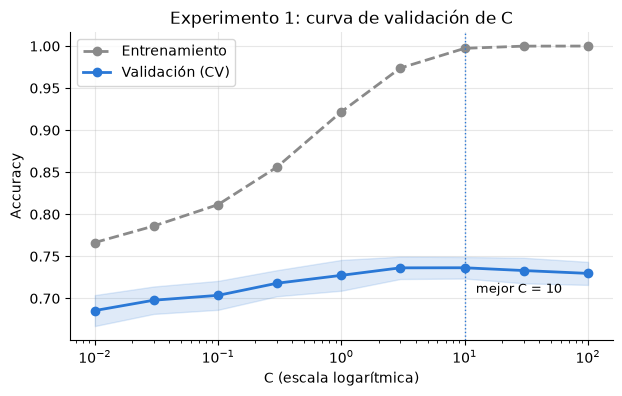

In [27]:
curva = tabla_e1.sort_values("C")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(curva["C"], curva["acc_train"], marker="o", color="#8a8a8a", linestyle="--", linewidth=2, label="Entrenamiento")
ax.plot(curva["C"], curva["acc_cv"], marker="o", color="#2a78d6", linewidth=2, label="Validación (CV)")
ax.fill_between(curva["C"], curva["acc_cv"] - curva["std_cv"], curva["acc_cv"] + curva["std_cv"],
                color="#2a78d6", alpha=0.15)

mejor_c = busqueda_e1.best_params_["clf__C"]
ax.axvline(mejor_c, color="#2a78d6", linestyle=":", linewidth=1)
ax.annotate(f"mejor C = {mejor_c}", xy=(mejor_c, curva["acc_cv"].max()), xytext=(8, -18),
            textcoords="offset points", fontsize=9)

ax.set_xscale("log")
ax.set_xlabel("C (escala logarítmica)")
ax.set_ylabel("Accuracy")
ax.set_title("Experimento 1: curva de validación de C")
ax.legend()
plt.show()

### 4.2 Evaluación en test

Test -> accuracy: 0.7238 | F1 macro: 0.7366

              precision    recall  f1-score   support

    negativo      0.608     0.616     0.612       843
     neutral      0.986     0.999     0.992       715
    positivo      0.612     0.599     0.605       842

    accuracy                          0.724      2400
   macro avg      0.736     0.738     0.737      2400
weighted avg      0.722     0.724     0.723      2400



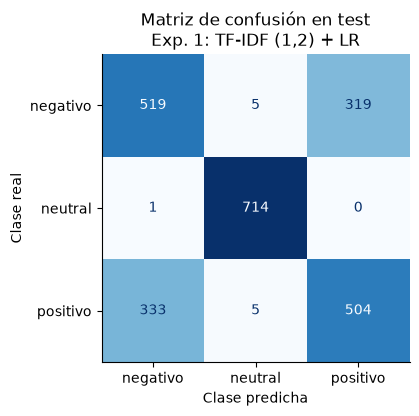

In [28]:
metricas_e1 = evaluar_en_test(busqueda_e1.best_estimator_, "Exp. 1: TF-IDF (1,2) + LR")

### 4.3 ¿Qué aprendió el modelo?

N-gramas con mayor coeficiente para cada clase: son los que más empujan la predicción hacia esa clase.

In [29]:
def top_coeficientes(modelo, n=15):
    vec = modelo.named_steps["tfidf"]
    clf = modelo.named_steps["clf"]
    nombres = vec.get_feature_names_out()
    tabla = {}
    for k, clase in enumerate(clf.classes_):
        orden = clf.coef_[k].argsort()[::-1][:n]
        tabla[clase] = [f"{nombres[i]} ({clf.coef_[k][i]:.2f})" for i in orden]
    return pd.DataFrame(tabla)[CLASES]

top_coeficientes(busqueda_e1.best_estimator_)

,negativo,neutral,positivo
0,pero (5.40),trae (4.11),supero todas (4.87)
1,defraudo todas (5.06),viene (3.85),supero (4.87)
2,defraudo (5.06),la caja (3.42),feliz (4.61)
3,mal (4.48),color (3.30),verdad (4.11)
4,resulto (4.30),por ahora (3.29),sin pensarlo (4.08)
5,muy (4.09),kilo (3.25),la verdad (4.03)
6,decepciono (4.08),unidades (3.25),me (3.93)
7,me decepciono (4.08),todavia (3.12),encanto (3.79)
8,nadie (4.08),viene en (3.01),me encanto (3.79)
9,defectuosa (4.03),el paquete (2.97),resistente (3.56)


### 4.4 Registro y envío

In [30]:
registrar_resultado(
    experimento=1,
    descripcion="Línea base: TF-IDF (1,2), min_df=2, sublinear + LR (ajuste de C)",
    busqueda=busqueda_e1,
    metricas_test=metricas_e1,
    envio="submission_01.csv",
)

,experimento,descripcion,mejores_params,acc_train,acc_cv,std_cv,f1_cv,acc_test,f1_test,envio,kaggle_publico
0,1,"Línea base: TF-IDF (1,2), min_df=2, sublinear + LR (ajuste de C)",{'clf__C': 10},0.9973,0.7364,0.0128,0.7478,0.7238,0.7366,submission_01.csv,None


In [31]:
envio_e1 = generar_envio(busqueda_e1, numero=1)

Envío guardado en envios/submission_01.csv y modelo en modelos/modelo_01.joblib
Distribución de predicciones en eval (%):
answer
negativo    36.9
neutral     27.8
positivo    35.2


### 4.5 Análisis del experimento 1

**Resultados:** accuracy de CV = **0,7364 ± 0,0128** (`C = 10`) y accuracy en test = **0,7238** (F1 macro 0,737).
La diferencia entre CV y test está dentro de una desviación estándar, así que la estimación es consistente.

1. **`neutral` está prácticamente resuelta:** recall 0,999 y precisión 0,986. Los coeficientes lo explican: el modelo
   asocia `neutral` a vocabulario descriptivo (`trae`, `viene`, `la caja`, `color`, `kilo`, `voltios`), tal como se
   vio en la exploración (sección 1.4). La sospecha inicial de que `neutral` sería la clase difícil era incorrecta.
2. **Todo el error está entre `negativo` y `positivo`:** 319 + 333 confusiones. Considerando solo esas dos clases, el
   modelo acierta (519 + 504) / 1.685 = **60,7 %**, apenas por encima del 50 % del azar. Es exactamente la dificultad
   que plantea el enunciado: ambas clases contienen elogios **y** quejas (`defraudo`, `decepciono`, `supero`, `feliz`
   aparecen en las dos), y lo que decide el sentimiento global es **cuál va al final o tras el conector**. Una bolsa de
   palabras, aun con bigramas, pierde ese orden.
3. **Sobreajuste fuerte:** entrenamiento ≈ 0,997 frente a 0,736 en validación. Sin embargo, la accuracy de validación
   es casi plana entre `C = 3` y `C = 100` (0,733–0,736): bajar `C` reduce la brecha pero no mejora la validación. El
   límite no es la regularización, sino que **la representación no contiene la información necesaria** (el orden).
   `C = 3` y `C = 10` empatan (0,7363 frente a 0,7364, diferencia muy inferior a la desviación entre folds).
4. **Coeficientes interpretables:** `pero` es el término con más peso hacia `negativo` (la queja suele ir después del
   "pero"), y `la verdad` hacia `positivo`. El modelo sí capta algo del papel de los conectores, pero solo como
   palabras sueltas, sin saber qué viene después de ellos.
5. **Predicciones en eval:** 36,9 % / 27,8 % / 35,2 %, una distribución similar a la de train.

**Implicación para los siguientes experimentos:** ajustes finos de la representación (experimento 2) probablemente
aporten poco, porque no atacan la confusión `negativo`/`positivo`. La mejora grande debería venir de las features que
codifican el **orden**: la cláusula tras el último conector contrastivo y la negación.